# 📊 Sales Data Analysis using SQL, Python & Visualization

### 👤 Author: Usman Haider

### 🎓 BS Data Science | GIFT University


## 📌 Project Overview

This project performs a comprehensive sales data analysis using SQL, Python, and visualization libraries to uncover patterns in revenue, product performance, customer behavior, and regional trends.


## 🎯 Objectives

* Analyze overall sales performance
* Identify top-performing products and categories
* Examine customer segments and purchasing behavior
* Analyze regional sales distribution
* Visualize key business insights using charts


## 🛠️ Tools & Technologies

* SQL (SQLite)
* Python (Pandas, NumPy)
* Data Visualization (Matplotlib, Seaborn)
* Jupyter Notebook


## 📊 Dataset Description

The dataset contains 9,800 sales records with detailed information including:

* Order details (Order ID, Order Date, Ship Date)
* Customer information (Customer ID, Segment)
* Product details (Category, Sub-category, Product Name)
* Geographic data (Region, State, City)
* Sales values


## ⚠️ Data Notes

* Minor missing values in Postal Code column
* Dataset contains a mix of high-value and low-value transactions



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv("train.csv")
print("Dataset Loaded!")
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Loaded!
Rows: 9800 | Columns: 18

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Exploration:

In [48]:
print("Basic Info:")
print(df.info())

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
d

### Insight:
Most columns are categorical (object type), while Sales and Postal Code are numerical, indicating the dataset is well-structured for both aggregation and statistical analysis.


In [51]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


### Insight:
Only the Postal Code column contains a small number of missing values (11), which is negligible and unlikely to significantly impact overall analysis.

In [52]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### Insight:
Sales values show high variability, with a large difference between minimum and maximum values, indicating the presence of both low-value and high-value transactions.

## SQL Analysis:

In [10]:
conn = sqlite3.connect(':memory:')
df.to_sql('sales', conn, index=False, if_exists='replace')
cursor = conn.cursor()

### Total Sales:

In [13]:
cursor.execute("""
SELECT 
COUNT(*) as total_orders,
ROUND(SUM(Sales), 2) as total_sales,
ROUND(AVG(Sales), 2) as avg_sales
FROM sales
""")
print("Overall Sales Summary:")
print(cursor.fetchone())

Overall Sales Summary:
(9800, 2261536.78, 230.77)


### Insight:
The dataset generated a total revenue of over 2.26 million across 9,800 transactions, with an average sale value of approximately 230.77, indicating moderate transaction sizes overall.

### Sales by Category:

In [24]:
cursor.execute("""
SELECT Category,
COUNT(*) as orders,
ROUND(SUM(Sales), 2) as total_sales,
ROUND(AVG(Sales), 2) as avg_sales
FROM Sales
GROUP BY Category
ORDER BY total_sales DESC
""")
print("Sales by Category:")
for row in cursor.fetchall():
    print(row)

Sales by Category:
('Technology', 1813, 827455.87, 456.4)
('Furniture', 2078, 728658.58, 350.65)
('Office Supplies', 5909, 705422.33, 119.38)


### Insight:
Technology products generate the highest revenue despite fewer transactions, indicating high-value sales, while Office Supplies have the highest number of orders but lower average sales per transaction.

### Sales By Region

In [23]:
cursor.execute("""
SELECT Region,
COUNT(*) as orders,
ROUND(SUM(Sales), 2) as total_sales
FROM sales
GROUP BY Region
ORDER BY total_sales DESC
""")
print("Sales by Region:")
for row in cursor.fetchall():
    print(row)

Sales by Region:
('West', 3140, 710219.68)
('East', 2785, 669518.73)
('Central', 2277, 492646.91)
('South', 1598, 389151.46)


### Insight:
The West region leads in total sales, followed closely by the East, while the South region generates the lowest revenue, indicating regional performance differences.

### Top 10 Products:

In [22]:
cursor.execute("""
SELECT "Product Name",
COUNT(*) as times_ordered,
ROUND(SUM(Sales), 2) as total_sales
FROM sales
GROUP BY "Product Name"
               ORDER BY total_sales DESC
               LIMIT 10
""")
print("Top 10 Products:")
for row in cursor.fetchall():
    print(row)

Top 10 Products:
('Canon imageCLASS 2200 Advanced Copier', 5, 61599.82)
('Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind', 10, 27453.38)
('Cisco TelePresence System EX90 Videoconferencing Unit', 1, 22638.48)
('HON 5400 Series Task Chairs for Big and Tall', 8, 21870.58)
('GBC DocuBind TL300 Electric Binding System', 11, 19823.48)
('GBC Ibimaster 500 Manual ProClick Binding System', 9, 19024.5)
('Hewlett Packard LaserJet 3310 Copier', 8, 18839.69)
('HP Designjet T520 Inkjet Large Format Printer - 24" Color', 3, 18374.9)
('GBC DocuBind P400 Electric Binding System', 6, 17965.07)
('High Speed Automatic Electric Letter Opener', 3, 17030.31)


### Insight:
A small number of high-value products contribute significantly to total revenue, with certain products generating exceptionally high sales despite low order frequency.

### Sales By Segment:

In [30]:
cursor.execute("""
SELECT Segment,
COUNT(*) as orders,
ROUND(SUM(Sales), 2) as total_sales,
ROUND(AVG(Sales), 2) as avg_order_value
FROM Sales
GROUP BY Segment
ORDER BY total_sales DESC
""")
print("Sales by Segment:")
for row in cursor.fetchall():
    print(row)

Sales by Segment:
('Consumer', 5101, 1148060.53, 225.07)
('Corporate', 2953, 688494.07, 233.15)
('Home Office', 1746, 424982.18, 243.4)


### Insight:
The Consumer segment contributes the highest overall revenue, while the Home Office segment shows the highest average sales per transaction, indicating higher spending per order.

## 🧠 Combined Insight:
The analysis shows that revenue is not evenly distributed across categories, regions, and customer segments. A small number of high-value products and customers contribute disproportionately to total sales, which is a common pattern in real-world business data.

# Visualizations:

### Sales by category:

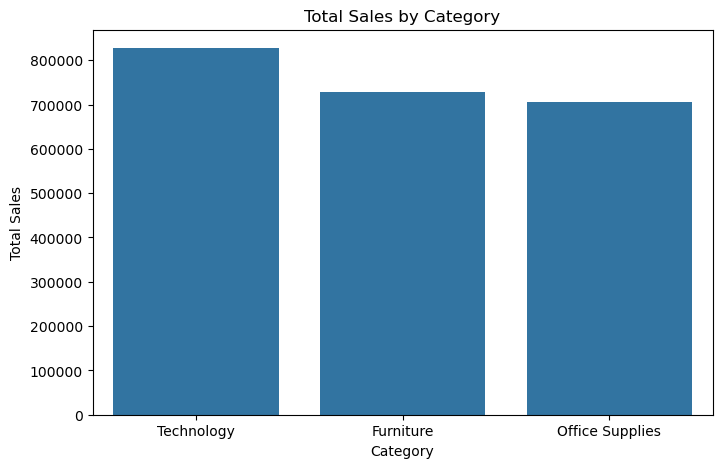

In [38]:
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Insight:
The visualization clearly shows that Technology dominates in revenue, highlighting it as a key business driver.

### Sales by Region:

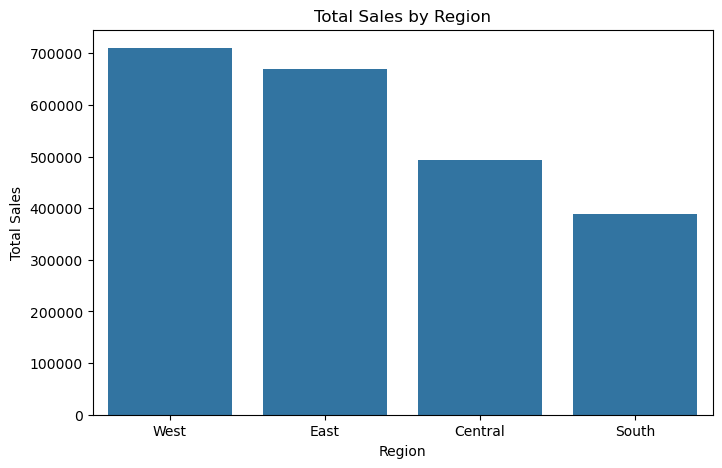

In [40]:
plt.figure(figsize=(8, 5))
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

### Insight:
Regional sales differences suggest that business performance varies geographically, indicating opportunities for market expansion in underperforming regions.

### Sales by Segment:

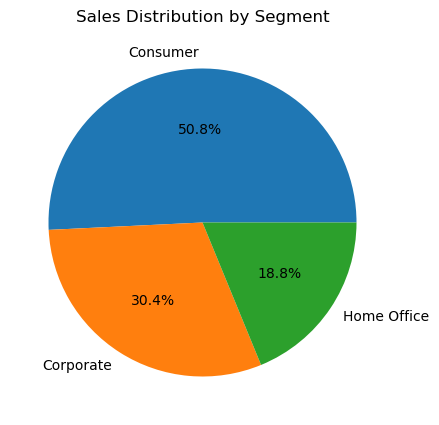

In [43]:
plt.figure(figsize=(8, 5))
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.pie(segment_sales.values, labels=segment_sales.index, autopct='%1.1f%%')
plt.title('Sales Distribution by Segment')
plt.show()

### Insight:
The Consumer segment dominates in total sales, but higher average spending in other segments indicates potential for targeted marketing strategies.

### Sales Distribution:

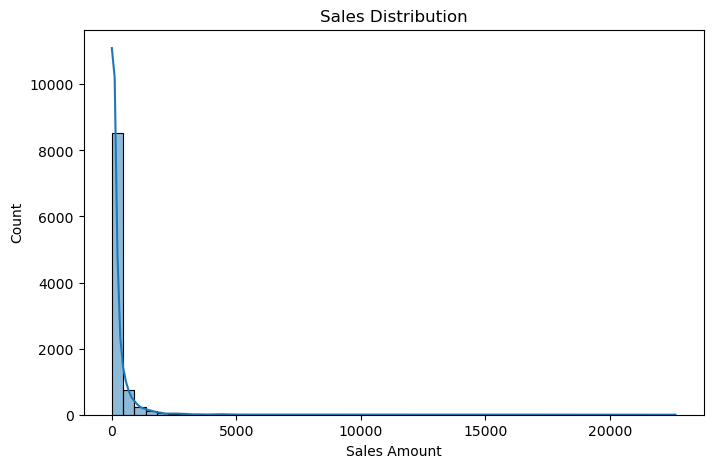

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.show()

### Top 10 Sub-Categories:

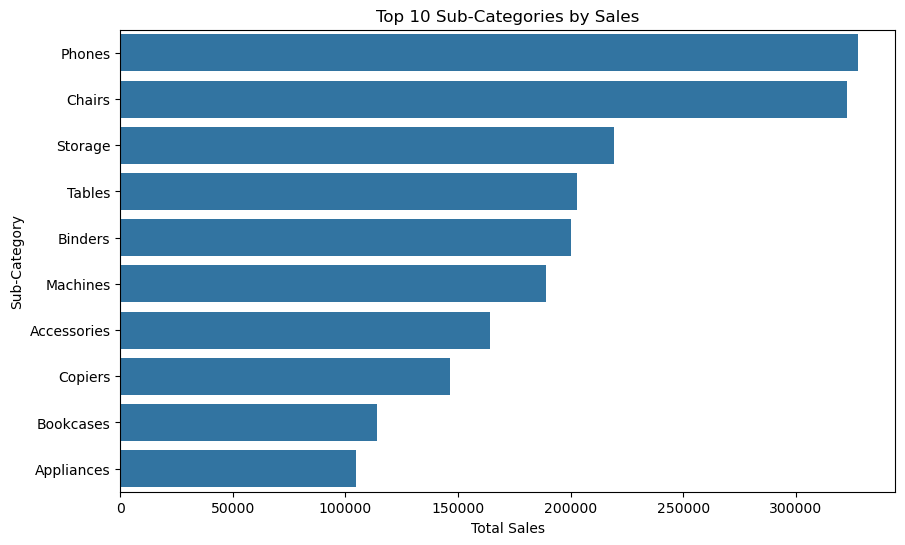

In [46]:
plt.figure(figsize=(10, 6))
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=subcategory_sales.values, y=subcategory_sales.index)
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales')
plt.show()

## 📊 Final Conclusion

The sales data analysis reveals important patterns in revenue generation, product performance, and customer behavior.

A significant portion of total revenue is driven by high-value products, particularly in the Technology category, which generates the highest sales despite having fewer transactions. In contrast, Office Supplies contribute the most in terms of order volume but generate lower revenue per transaction.

Regional analysis shows that the West and East regions are the top-performing markets, while the South region lags behind, indicating potential opportunities for growth and expansion.

Customer segmentation highlights that the Consumer segment contributes the highest overall revenue, while the Home Office segment demonstrates higher average spending per transaction, suggesting different purchasing behaviors across segments.

Overall, the analysis demonstrates that business performance is influenced by product category, regional demand, and customer segments, emphasizing the importance of targeted strategies for maximizing revenue and growth.


## ⚠️ Limitations

* The dataset contains missing values in the Postal Code column, which may slightly affect location-based analysis.

* The dataset does not include profit or cost information, limiting the ability to analyze business profitability.

* External factors such as marketing campaigns, seasonal trends, and economic conditions are not included, which may influence sales performance.

* Customer demographic details are limited, restricting deeper behavioral analysis.

* The analysis is based on historical data and may not fully represent current or future business trends.
